<a href="https://colab.research.google.com/github/rpaulos/CCMACLRL_EXERCISES_COM232/blob/main/Exercise4/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Hate Speech Classification using Multinomial Naive Bayes

Instructions:
- You do not need to split your data. Use the training, validation and test sets provided below.
- Use Multinomial Naive Bayes to train a model that can classify if a sentence is a hate speech or non-hate speech
- A sentence with a label of zero (0) is classified as non-hate speech
- A sentence with a label of one (1) is classified as a hate speech

Apply text pre-processing techniques such as
- Converting to lowercase
- Stop word Removal
- Removal of digits, special characters
- Stemming or Lemmatization but not both
- Count Vectorizer or TF-IDF Vectorizer but not both

Evaluate your model by:
- Providing input by yourself
- Creating a Confusion Matrix
- Calculating the Accuracy, Precision, Recall and F1-Score

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score, accuracy_score, balanced_accuracy_score

from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [2]:
splits = {'train': 'unique_train_dataset.csv', 'validation': 'unique_validation_dataset.csv', 'test': 'unique_test_dataset.csv'}

**Training Set**

Use this to train your model

In [3]:
df_train = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["train"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


**Validation Set**

Use this set to evaluate your model

In [4]:
df_validation = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["validation"])

**Test Set**
  
Use this set to test your model

In [5]:
df_test = pd.read_csv("hf://datasets/mapsoriano/2016_2022_hate_speech_filipino/" + splits["test"])

## A. Understanding your training data

1. Check the first 10 rows of the training dataset

In [6]:
# put your answer here
df_train.head(10)

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1
5,"""Ang sinungaling sa umpisa ay sinungaling hang...",1
6,Leni Kiko,0
7,Nahiya si Binay sa Makati kaya dito na lang sa...,1
8,Another reminderHalalan,0
9,[USERNAME] Maybe because VP Leni Sen Kiko and ...,0


2. Check how many rows and columns are in the training dataset using `.info()`

In [7]:
# put your answer here
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21773 entries, 0 to 21772
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    21773 non-null  object
 1   label   21773 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 340.3+ KB


3. Check for NaN values

In [8]:
# put your answer here
df_train.isna()

,text,label
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
21768,False,False
21769,False,False
21770,False,False
21771,False,False


In [9]:
df_train.isna().sum()

,0
text,0
label,0


4. Check for duplicate rows

In [10]:
# put your answer here
df_train.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21768,False
21769,False
21770,False
21771,False


In [11]:
df_train.duplicated().sum()

np.int64(0)

5. Check how many rows belong to each class

In [12]:
# put your answer here
df_train.count()

,0
text,21773
label,21773


## B. Text pre-processing

6. Remove duplicate rows

In [13]:
# put your answer here
df_train.drop_duplicates()

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1
...,...,...
21768,Marcos Talunan Marcos Magnanakaw,1
21769,Grabe kayo kay binay ??????????,0
21770,[USERNAME] Cnu ba naman ang hindImabibighani s...,0
21771,RT [USERNAME]: Tabi tabi yung mga nagsasabing ...,1


7. Remove rows with NaN values

In [14]:
# put your answer here
df_train.dropna()

,text,label
0,Presidential candidate Mar Roxas implies that ...,1
1,Parang may mali na sumunod ang patalastas ng N...,1
2,Bet ko. Pula Ang Kulay Ng Posas,1
3,[USERNAME] kakampink,0
4,Bakit parang tahimik ang mga PINK about Doc Wi...,1
...,...,...
21768,Marcos Talunan Marcos Magnanakaw,1
21769,Grabe kayo kay binay ??????????,0
21770,[USERNAME] Cnu ba naman ang hindImabibighani s...,0
21771,RT [USERNAME]: Tabi tabi yung mga nagsasabing ...,1


8. Convert all text to lowercase

In [15]:
# put your answer here
df_train['text'] = df_train['text'].str.lower()

9. Remove digits, URLS and special characters

In [16]:
# put your answer here
def clean_text(s):
    s = re.sub(r'http\S+|www\.\S+', '', s)
    s = re.sub(r'\d+', '', s)
    s = re.sub(r'[^A-Za-z\s]', '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_train = df_train.apply(lambda col: col.apply(clean_text) if col.dtype == 'object' else col)

print(df_train)

                                                    text  label
0      presidential candidate mar roxas implies that ...      1
1      parang may mali na sumunod ang patalastas ng n...      1
2                         bet ko pula ang kulay ng posas      1
3                                     username kakampink      0
4      bakit parang tahimik ang mga pink about doc wi...      1
...                                                  ...    ...
21768                   marcos talunan marcos magnanakaw      1
21769                               grabe kayo kay binay      0
21770  username cnu ba naman ang hindimabibighani sa ...      0
21771  rt username tabi tabi yung mga nagsasabing par...      1
21772  honestly i dont get kakampinks like pano nila ...      1

[21773 rows x 2 columns]


10. Remove stop words

In [17]:
# put your answer here
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    words = re.findall(r'\b\w+\b', text.lower())
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

df_train['text'] = df_train['text'].apply(remove_stopwords)
print(df_train)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                    text  label
0      presidential candidate mar roxas implies govt ...      1
1      parang may mali na sumunod ang patalastas ng n...      1
2                         bet ko pula ang kulay ng posas      1
3                                     username kakampink      0
4      bakit parang tahimik ang mga pink doc willie o...      1
...                                                  ...    ...
21768                   marcos talunan marcos magnanakaw      1
21769                               grabe kayo kay binay      0
21770  username cnu ba naman ang hindimabibighani sa ...      0
21771  rt username tabi tabi yung mga nagsasabing par...      1
21772  honestly dont get kakampinks like pano nila na...      1

[21773 rows x 2 columns]


11. Use Stemming or Lemmatization

In [18]:
# # put your answer here
# stemmer = PorterStemmer()

# def stemming(text):
#   if not isinstance(text, str):
#     return text

#   words = re.findall(r'\b\w+\b', text.lower())
#   stems = [stemmer.stem(w) for w in words if w not in stop_words]

#   return ''.join(stems)

# df_train['text'] = df_train['text'].apply(stemming)
# print(df_train)

In [19]:
# put your answer here

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')   # for better coverage of WordNet data

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    if not isinstance(text, str):
        return text

    words = re.findall(r'\b\w+\b', text.lower())
    # lemmatize each word that is not a stopword
    lemmas = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    # join lemmas back into a string
    return ' '.join(lemmas)

df_train['text'] = df_train['text'].apply(lemmatize_text)
print(df_train)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                                    text  label
0      presidential candidate mar roxas implies govt ...      1
1      parang may mali na sumunod ang patalastas ng n...      1
2                         bet ko pula ang kulay ng posas      1
3                                     username kakampink      0
4      bakit parang tahimik ang mga pink doc willie o...      1
...                                                  ...    ...
21768                   marcos talunan marcos magnanakaw      1
21769                               grabe kayo kay binay      0
21770  username cnu ba naman ang hindimabibighani sa ...      0
21771  rt username tabi tabi yung mga nagsasabing par...      1
21772  honestly dont get kakampinks like pano nila na...      1

[21773 rows x 2 columns]


## C. Training your model

12. Put all text training data in variable **X_train**

In [20]:
# put your answer here
X_train = df_train['text']

13. Put all training data labels in variable **y_train**

In [21]:
# put your answer here
y_train = df_train['label']

14. Use `CountVectorizer()` or `TfidfVectorizer()` to convert text data to its numerical form.

Put the converted data to **X_train_transformed** variable

In [22]:
# put your answer here
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)

15. Create an instance of `MultinomalNB()`

In [23]:
# put your answer here
model = MultinomialNB(alpha=0.1)

16. Train the model using `.fit()`

In [24]:
# put your answer here
model.fit(X_train_vectorized, y_train)

MultinomialNB(alpha=0.1)

## D. Evaluate your model

17. Use `.predict()` to generate model predictions using the **validation dataset**


- Put all text validation data in **X_validation** variable

- Convert **X_validation** to its numerical form.

- Put the converted data to **X_validation_transformed**

- Put all predictions in **y_validation_pred** variable

In [25]:
# put your answer here
X_validation = df_validation['text']
X_validation_vectorized = vectorizer.transform(X_validation)
y_validation_pred = model.predict(X_validation_vectorized)

18. Get the Accuracy, Precision, Recall and F1-Score of the model using the **validation dataset**

- Put all validation data labels in **y_validation** variable

In [26]:
# put your answer here
y_validation = df_validation['label']

In [27]:
# Accuracy Score
print((accuracy_score(y_validation, y_validation_pred)))

0.8260714285714286


In [28]:
# Precision
print((precision_score(y_validation, y_validation_pred)))

0.7925598991172762


In [29]:
# Recall
print((recall_score(y_validation, y_validation_pred)))

0.888339222614841


In [30]:
# F1 Score
print((f1_score(y_validation, y_validation_pred)))

0.8377207597467511


19. Create a confusion matrix using the **validation dataset**

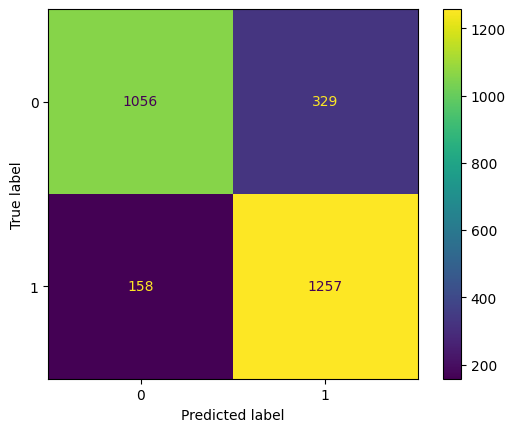

In [31]:
# put your answer here
matrix = confusion_matrix(y_validation, y_validation_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=model.classes_)
disp.plot()

20. Use `.predict()` to generate the model predictions using the **test dataset**


- Put all text validation data in **X_test** variable

- Convert **X_test** to its numerical form.

- Put the converted data to **X_test_transformed**

- Put all predictions in **y_test_pred** variable

In [32]:
# put your answer here
X_test = df_test['text']
X_test_vectorize = vectorizer.transform(X_test)
y_test_pred = model.predict(X_test_vectorize)

21. Get the Accuracy, Precision, Recall and F1-Score of the model using the **test dataset**

- Put all test data labels in **y_validation** variable



In [33]:
# put your answer here
y_test = df_test['label']

In [34]:
# Accuracy
print((accuracy_score(y_test, y_test_pred)))

0.8274021352313167


In [35]:
# Precission
print((precision_score(y_test, y_test_pred)))

0.7947062621045836


In [36]:
# Recall
print((recall_score(y_test, y_test_pred)))

0.8805436337625179


In [37]:
# F1-Score
print(f1_score(y_test, y_test_pred))

0.835425856803529


22. Create a confusion matrix using the **test dataset**

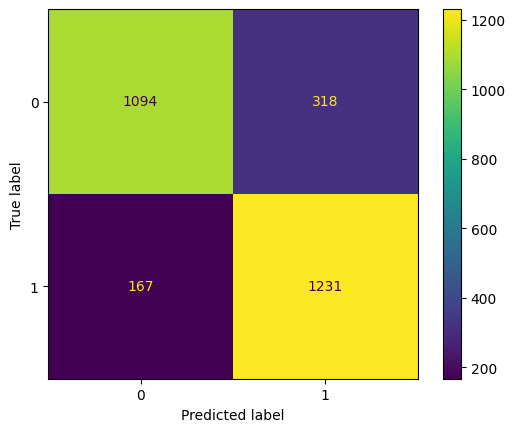

In [38]:
# put your answer here
matrix = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=model.classes_)
disp.plot()

## E. Test the model

23. Test the model by providing a non-hate speech input. The model should predict it as 0

In [39]:
# put your answer here
test_input = ["Let Leni Lead"]
test_input_transformed = vectorizer.transform(test_input)
prediction = model.predict(test_input_transformed)
print("Prediction:", prediction[0])

Prediction: 0


24. Test the model by providing a hate speech input. The model should predict it as 1

In [40]:
# put your answer here
test_input = ["You are worthless!"]
test_input_transformed = vectorizer.transform(test_input)
prediction = model.predict(test_input_transformed)
print("Prediction:", prediction[0])

Prediction: 1
